# Laboratorio 1 — Series de Tiempo
## 3. Modelado y predicción (inciso 4.f–k y ejercicio 5)
**Universidad del Valle de Guatemala · Facultad de Ingeniería · Departamento de Ciencias de la Computación**
**CC3084 — Data Science · Semestre II 2026**

**Grupo:** Dulce Ambrosio · Daniel Chet · Javier Linares

**Carnt(s):** 231143 · 231177 · 231135

Este cuaderno continúa el trabajo de `01_limpieza_eda` (inciso 1) y `02_series_tiempo`
(incisos 2, 3 y el análisis preliminar 4.a–e de Total, Vía Aérea, Vía Terrestre y Tipo Turista).
Aquí se completa el análisis 4.a–e de las **cuatro series que faltaban** (Vía Marítima, Tipo
Excursionista, Tipo Viajero, Tipo Cruceristas) y se hace el **modelado completo (4.f–k)** de las
**ocho series** con ARIMA/SARIMA (manual y por búsqueda de AIC), Prophet, Holt-Winters,
suavizamiento exponencial simple y seasonal naive, cerrando con el **análisis comparativo
(ejercicio 5)** entre categorías.

In [ ]:
import sys
import warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from IPython.display import display
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

warnings.filterwarnings("ignore")

ROOT = Path.cwd().parents[1] if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.append(str(ROOT / '01_limpieza_eda' / 'src'))
sys.path.append(str(ROOT / '02_series_tiempo' / 'src'))
sys.path.append(str(ROOT / '03_modelado_prediccion' / 'src'))
import config, series, modelado as mod

config.aplicar_estilo()
MILES = FuncFormatter(config.miles)
P = config.PALETTE

df = series.cargar_limpio()
print('Datos limpios:', len(df), 'registros,', df['fecha'].nunique(), 'meses')

Datos limpios: 161015 registros, 210 meses


In [ ]:
# Reconstrucción de las 8 series (idéntico a 02_analisis_preliminar_series.ipynb)
series_dict = {'Total': series.serie_mensual(df)}
for v in ['Aérea', 'Terrestre', 'Marítima']:
    series_dict[f'Vía: {v}'] = series.serie_mensual(df, 'Vía', v)
tipos = list(df['Tipo de Viajero'].value_counts().index)
for t in tipos:
    series_dict[f'Tipo: {t}'] = series.serie_mensual(df, 'Tipo de Viajero', t)
list(series_dict.keys())

['Total',
 'Vía: Aérea',
 'Vía: Terrestre',
 'Vía: Marítima',
 'Tipo: Turista',
 'Tipo: Viajero',
 'Tipo: Excursionista',
 'Tipo: Cruceristas']

## Parte A — Análisis preliminar de las series faltantes (inciso 4.a–e)

El cuaderno `02` ya cubrió a detalle Total mensual, Vía Aérea, Vía Terrestre y Tipo Turista.
Aquí completamos el mismo análisis (inicio/fin/frecuencia, gráfico, descomposición, ACF/PACF,
ADF/KPSS) para las cuatro series restantes: **Vía Marítima**, **Tipo Excursionista**,
**Tipo Viajero** y **Tipo Cruceristas**.

### Serie: Vía Marítima (inciso 4.a–e)

=== Vía Marítima ===
Inicio: 2009-01-01 | Fin: 2021-03-01 | Frecuencia: Mensual (MS) | n = 147
ADF niveles      : stat=-0.99  p=0.757  -> NO estacionaria (5%)
ADF 1a diferencia: stat=-4.12  p=0.001  -> estacionaria (5%)
KPSS niveles     : stat=0.121  p=0.100  -> estacionaria (5%)


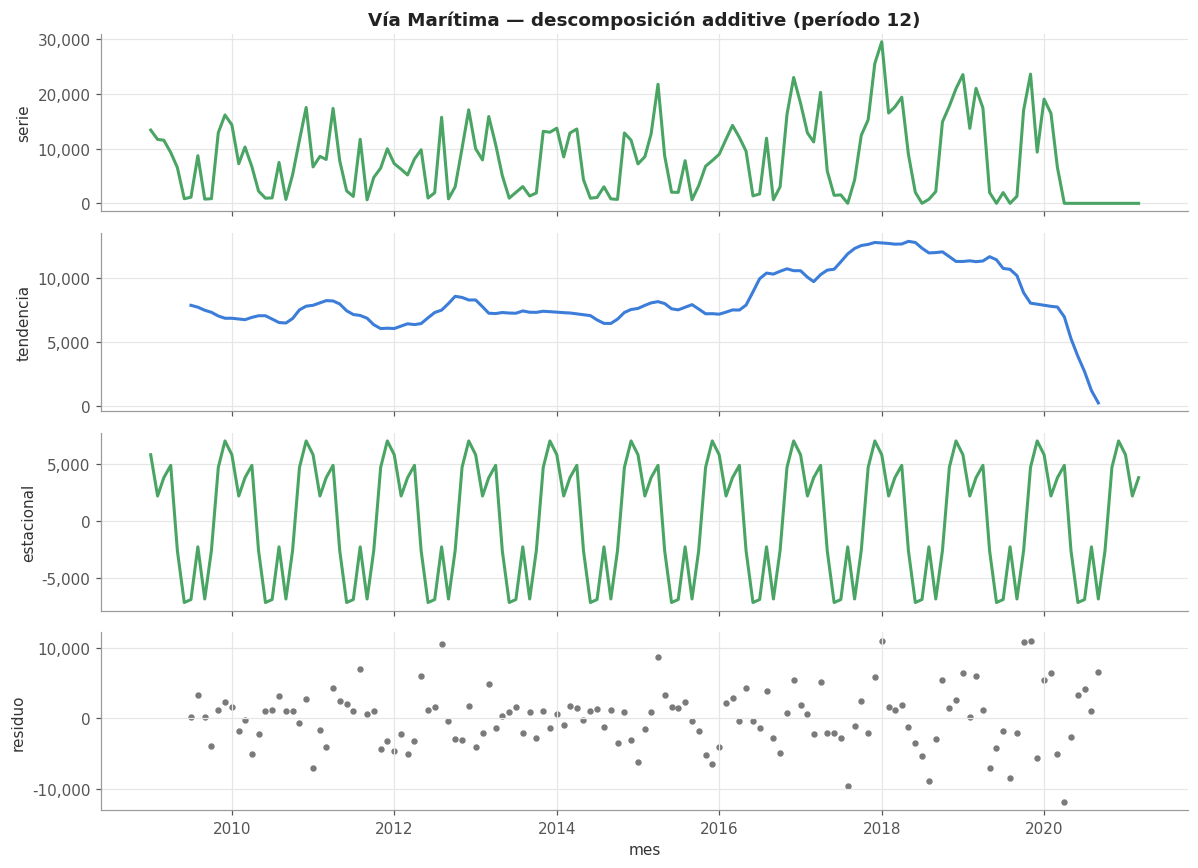

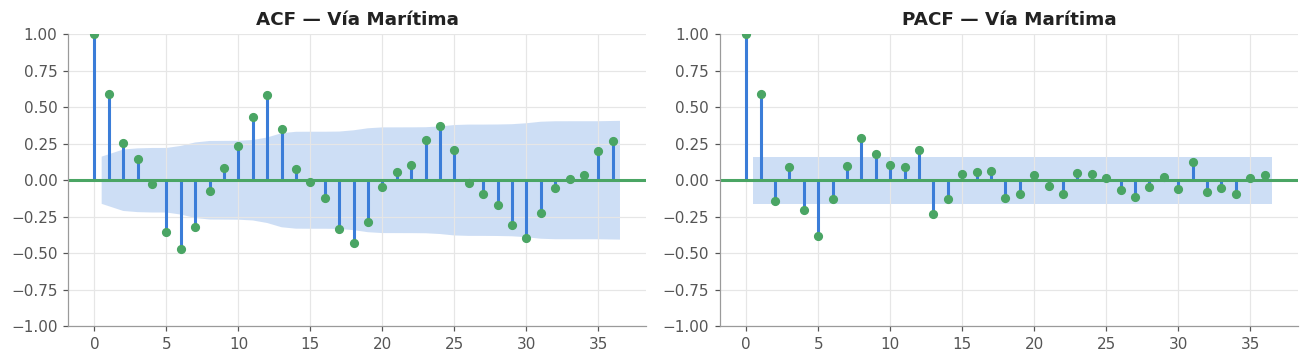

Fuerza de tendencia: 0.31  |  Fuerza estacional: 0.61


In [ ]:
a0, a1, k0 = series.analiza_serie('Vía Marítima', series_dict['Vía: Marítima'], 'via_maritima', P['verde'])
fza = series.fuerza_estacional_tendencia(series.split_temporal(series_dict['Vía: Marítima'])[0])
print(f"Fuerza de tendencia: {fza['fuerza_tendencia']:.2f}  |  Fuerza estacional: {fza['fuerza_estacional']:.2f}")

**Interpretación — Vía Marítima.**
Es la serie de menor volumen y la más irregular de las tres vías: varios meses de entrenamiento
en cero (barcos que no atracaron ese mes) y una media de apenas 7,991 viajeros mensuales,
muy por debajo de los ~90 mil de Aérea o ~140 mil de Terrestre. La fuerza estacional
(0.61) es, de hecho, la más alta de las tres vías, coherente con que los cruceros
siguen una temporada bastante marcada (noviembre–abril). La ADF en niveles no rechaza raíz
unitaria (p=0.76) pero sí lo hace tras una diferenciación (p=0.0009),
así que no es estacionaria en media y necesita d=1; por los ceros frecuentes la descomposición
se hace en modo aditivo, no multiplicativo.

### Serie: Tipo Excursionista (inciso 4.a–e)

=== Tipo Excursionista ===
Inicio: 2009-01-01 | Fin: 2021-03-01 | Frecuencia: Mensual (MS) | n = 147
ADF niveles      : stat=-2.13  p=0.232  -> NO estacionaria (5%)
ADF 1a diferencia: stat=-4.72  p=0.000  -> estacionaria (5%)
KPSS niveles     : stat=0.504  p=0.041  -> NO estacionaria (5%)


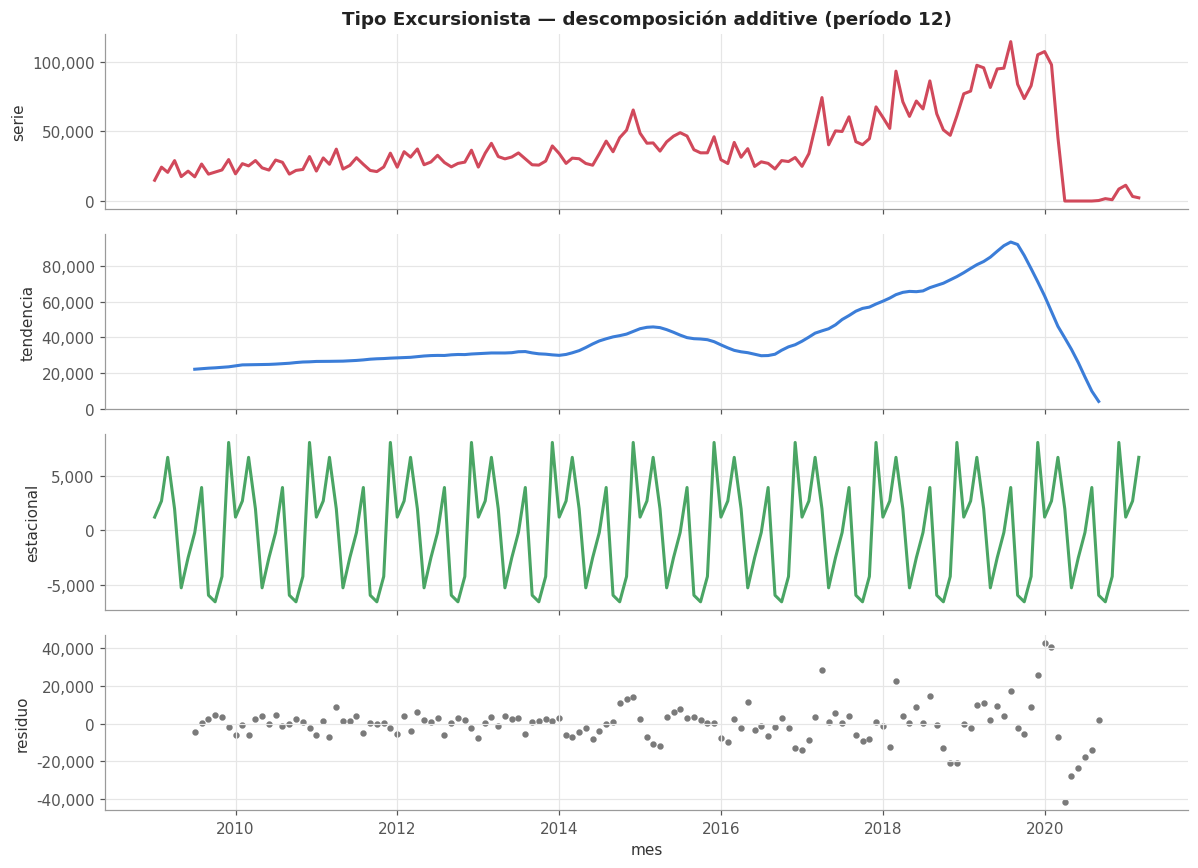

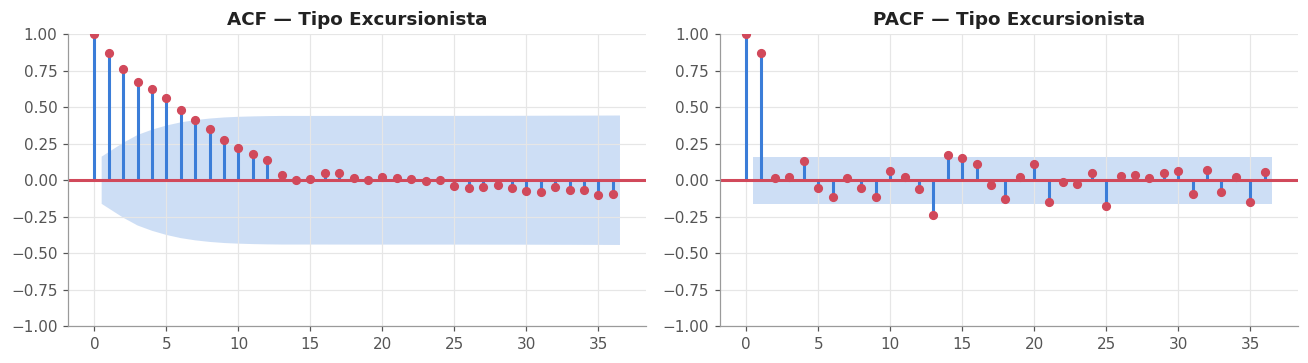

Fuerza de tendencia: 0.74  |  Fuerza estacional: 0.10


In [ ]:
a0, a1, k0 = series.analiza_serie('Tipo Excursionista', series_dict['Tipo: Excursionista'], 'tipo_excursionista', P['rojo'])
fza = series.fuerza_estacional_tendencia(series.split_temporal(series_dict['Tipo: Excursionista'])[0])
print(f"Fuerza de tendencia: {fza['fuerza_tendencia']:.2f}  |  Fuerza estacional: {fza['fuerza_estacional']:.2f}")

**Interpretación — Tipo Excursionista.**
Acompaña a Turista en tendencia (fuerza de tendencia 0.74) pero con una
estacionalidad mucho más débil (0.10) — tiene sentido, porque el excursionista
(que no pernocta) depende menos de vacaciones largas y más del tránsito fronterizo cotidiano.
La ADF en niveles no rechaza la raíz unitaria (p=0.23); tras d=1 sí lo hace
(p=0.00008). No estacionaria en media ni en varianza (conviene log).

### Serie: Tipo Viajero (inciso 4.a–e)

=== Tipo Viajero ===
Inicio: 2009-01-01 | Fin: 2021-03-01 | Frecuencia: Mensual (MS) | n = 147
ADF niveles      : stat=-2.13  p=0.232  -> NO estacionaria (5%)
ADF 1a diferencia: stat=-5.24  p=0.000  -> estacionaria (5%)
KPSS niveles     : stat=0.847  p=0.010  -> NO estacionaria (5%)


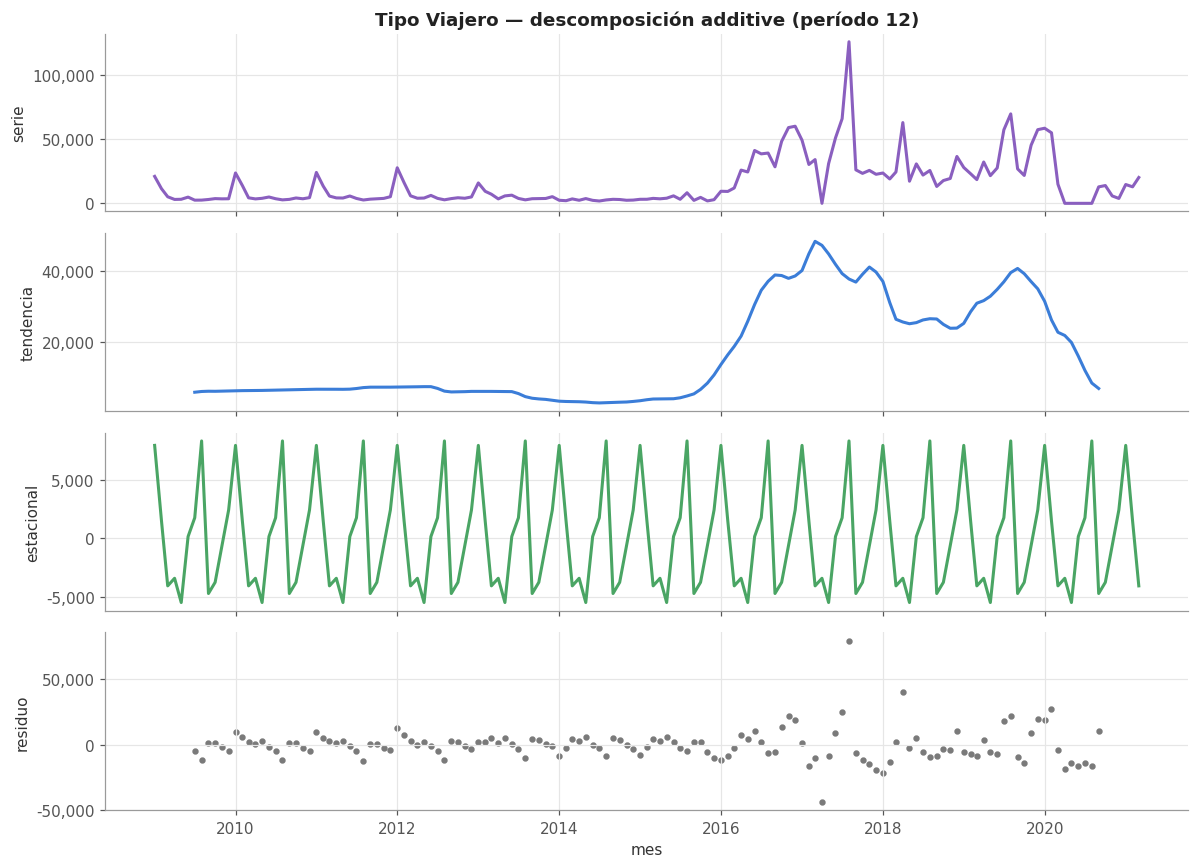

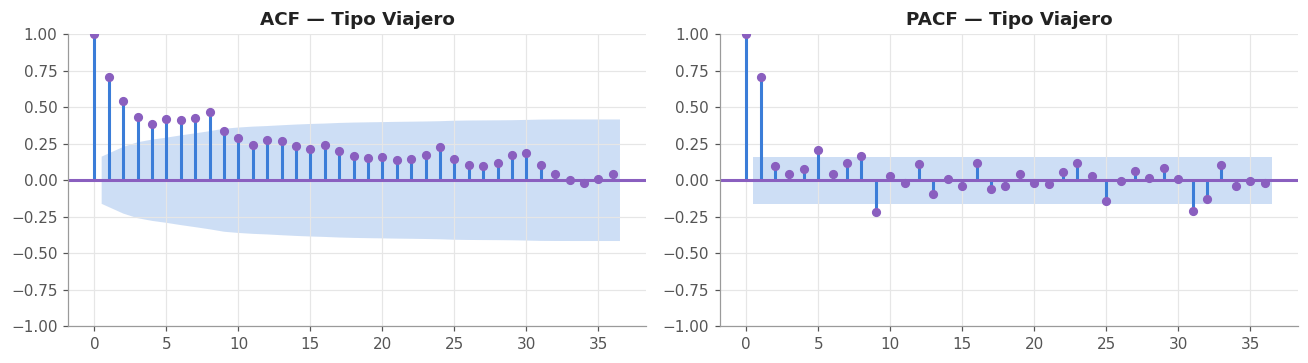

Fuerza de tendencia: 0.48  |  Fuerza estacional: 0.10


In [ ]:
a0, a1, k0 = series.analiza_serie('Tipo Viajero', series_dict['Tipo: Viajero'], 'tipo_viajero', P['morado'])
fza = series.fuerza_estacional_tendencia(series.split_temporal(series_dict['Tipo: Viajero'])[0])
print(f"Fuerza de tendencia: {fza['fuerza_tendencia']:.2f}  |  Fuerza estacional: {fza['fuerza_estacional']:.2f}")

**Interpretación — Tipo Viajero.**
Es la serie más volátil de las ocho (coeficiente de variación 1.22) y con la tendencia y
estacionalidad más débiles de su categoría (tendencia 0.48, estacional
0.10). Esto coincide con lo ya documentado en el EDA: la definición de "Viajero"
cambia en 2023 y excluye tránsito/comercio fronterizo de alta frecuencia, así que buena parte de
lo que aquí se lee como "ruido" es en realidad un quiebre metodológico, no una señal real del
mercado. La ADF en niveles no rechaza raíz unitaria (p=0.23) y KPSS sí rechaza
estacionariedad en niveles (p=0.01); tras d=1 la ADF rechaza con mucha fuerza
(p=7.34e-06).

### Serie: Tipo Cruceristas (inciso 4.a–e)

=== Tipo Cruceristas ===
Inicio: 2009-01-01 | Fin: 2018-01-01 | Frecuencia: Mensual (MS) | n = 109
ADF niveles      : stat=0.59  p=0.987  -> NO estacionaria (5%)
ADF 1a diferencia: stat=-8.14  p=0.000  -> estacionaria (5%)
KPSS niveles     : stat=0.326  p=0.100  -> estacionaria (5%)


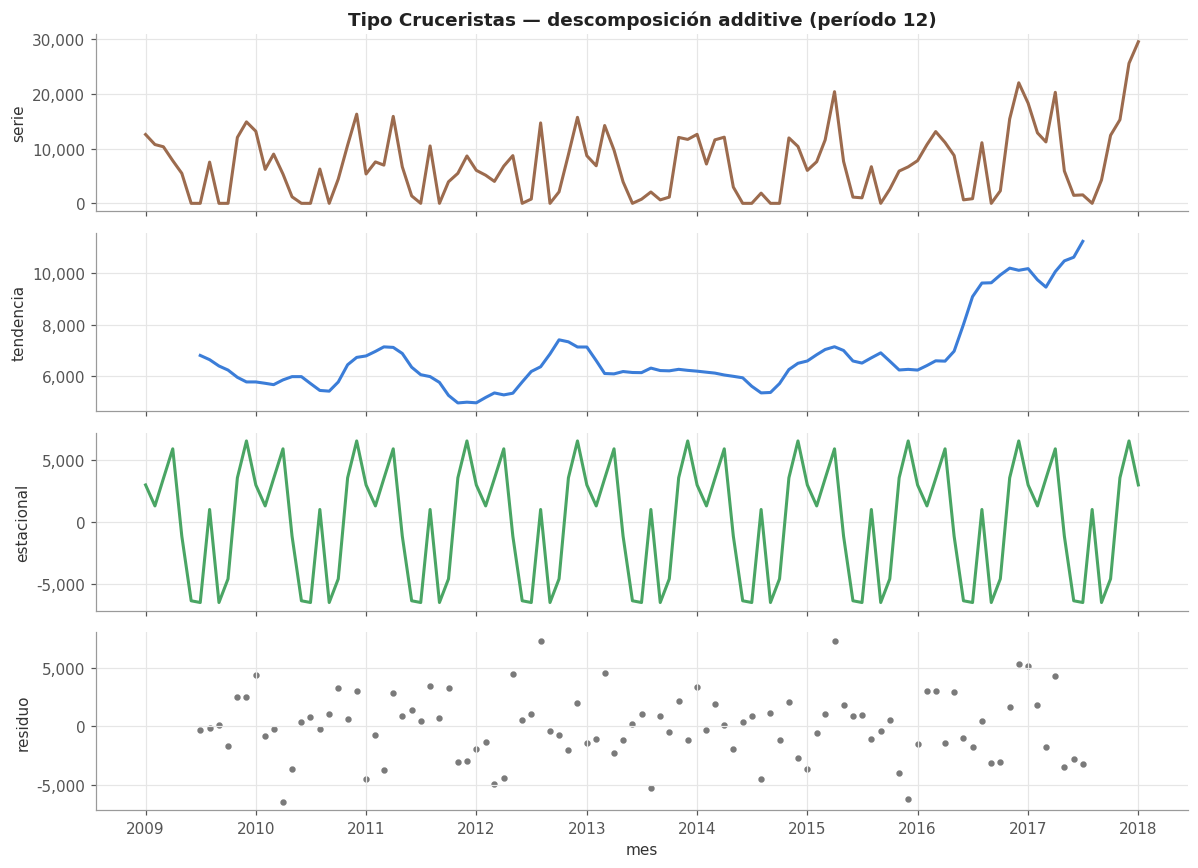

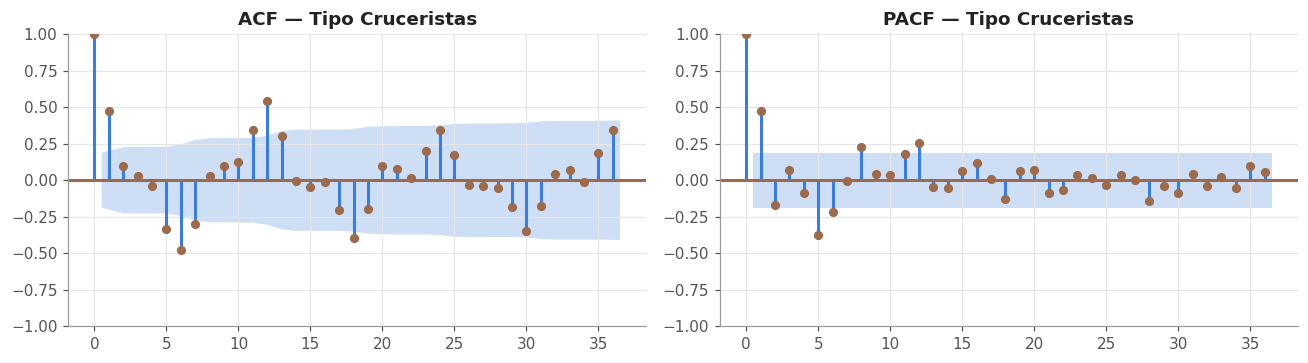

Fuerza de tendencia: 0.15  |  Fuerza estacional: 0.65


In [ ]:
a0, a1, k0 = series.analiza_serie('Tipo Cruceristas', series_dict['Tipo: Cruceristas'], 'tipo_cruceristas', P['cafe'])
fza = series.fuerza_estacional_tendencia(series.split_temporal(series_dict['Tipo: Cruceristas'])[0])
print(f"Fuerza de tendencia: {fza['fuerza_tendencia']:.2f}  |  Fuerza estacional: {fza['fuerza_estacional']:.2f}")

**Interpretación — Tipo Cruceristas.**
Esta categoría solo existe entre 2009 y 2021 (después, INGUAT deja de reportarla por separado),
así que la serie completa tiene 156 meses en vez de 210, y su propio corte 70/30 termina
antes de la pandemia entrar de lleno. Es, junto con Vía Marítima, la serie con mayor fuerza
estacional (0.65) — de hecho ambas series describen casi el mismo fenómeno (cruceros
que entran por vía marítima), lo cual es un buen chequeo de consistencia interna del dataset.
La ADF en niveles no rechaza raíz unitaria (p=0.99); tras d=1 rechaza con fuerza
(p=1.04e-12).